In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
import kagglehub
path = kagglehub.dataset_download("preetviradiya/brian-tumor-dataset")

Using Colab cache for faster access to the 'brian-tumor-dataset' dataset.


In [ ]:
import os
print(os.listdir(path))

['metadata_rgb_only.csv', 'Brain Tumor Data Set', 'metadata.csv']


In [ ]:
print(os.listdir(os.path.join(path, "Brain Tumor Data Set")))

['Brain Tumor Data Set']


In [ ]:
DATA_DIR = os.path.join(path, "Brain Tumor Data Set", "Brain Tumor Data Set")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
print(os.listdir(DATA_DIR))

['Brain Tumor', 'Healthy']


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42


In [ ]:
def load_image_paths(data_dir):
    filepaths = []
    labels = []

    for label_name in os.listdir(data_dir):
        class_dir = os.path.join(data_dir, label_name)

        if os.path.isdir(class_dir):
            for file in os.listdir(class_dir):
                filepaths.append(os.path.join(class_dir, file))
                labels.append(label_name)

    return np.array(filepaths), np.array(labels)

In [ ]:
def split_data(filepaths, labels):
    X_train, X_temp, y_train, y_temp = train_test_split(
        filepaths, labels,
        test_size=0.3,
        stratify=labels,
        random_state=SEED
    )

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp,
        test_size=0.5,
        stratify=y_temp,
        random_state=SEED
    )

    return X_train, X_val, X_test, y_train, y_val, y_test

In [ ]:
def get_train_augmentation():
    return ImageDataGenerator(
        rotation_range=10,
        zoom_range=0.1,
        horizontal_flip=True,
        width_shift_range=0.05,
        height_shift_range=0.05
    )



In [ ]:
def get_val_test_augmentation():
    return ImageDataGenerator()


In [ ]:
def create_generators(data_dir):

    filepaths, labels = load_image_paths(data_dir)

    X_train, X_val, X_test, y_train, y_val, y_test = split_data(filepaths, labels)

    train_df = pd.DataFrame({"filename": X_train, "class": y_train})
    val_df = pd.DataFrame({"filename": X_val, "class": y_val})
    test_df = pd.DataFrame({"filename": X_test, "class": y_test})

    train_gen = get_train_augmentation().flow_from_dataframe(
        train_df,
        x_col="filename",
        y_col="class",
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="binary"
    )

    val_gen = get_val_test_augmentation().flow_from_dataframe(
        val_df,
        x_col="filename",
        y_col="class",
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="binary"
    )

    test_gen = get_val_test_augmentation().flow_from_dataframe(
        test_df,
        x_col="filename",
        y_col="class",
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="binary",
        shuffle=False
    )

    return train_gen, val_gen, test_gen

In [ ]:
with open("data_loader.py", "w") as f:
    f.write("""

""")

In [ ]:
import os
print(os.listdir())

['.config', '__pycache__', 'data_loader.py', 'sample_data']


In [ ]:
with open("data_loader.py", "r") as f:
    print(f.read())


# paste your full data_loader code here



In [ ]:
import importlib
import data_loader
importlib.reload(data_loader)

<module 'data_loader' from '/content/data_loader.py'>

In [ ]:
with open("data_loader.py", "w") as f:
    f.write("""
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

def load_image_paths(data_dir):
    filepaths = []
    labels = []

    for label_name in os.listdir(data_dir):
        class_dir = os.path.join(data_dir, label_name)

        if os.path.isdir(class_dir):
            for file in os.listdir(class_dir):
                filepaths.append(os.path.join(class_dir, file))
                labels.append(label_name)

    return np.array(filepaths), np.array(labels)

def split_data(filepaths, labels):
    X_train, X_temp, y_train, y_temp = train_test_split(
        filepaths, labels,
        test_size=0.3,
        stratify=labels,
        random_state=SEED
    )

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp,
        test_size=0.5,
        stratify=y_temp,
        random_state=SEED
    )

    return X_train, X_val, X_test, y_train, y_val, y_test

def get_train_augmentation():
    return ImageDataGenerator(
        rescale=1./255,
        rotation_range=10,
        zoom_range=0.1,
        horizontal_flip=True,
        width_shift_range=0.05,
        height_shift_range=0.05
    )

def get_val_test_augmentation():
    return ImageDataGenerator(rescale=1./255)

def create_generators(data_dir):

    filepaths, labels = load_image_paths(data_dir)

    X_train, X_val, X_test, y_train, y_val, y_test = split_data(filepaths, labels)

    train_df = pd.DataFrame({"filename": X_train, "class": y_train})
    val_df = pd.DataFrame({"filename": X_val, "class": y_val})
    test_df = pd.DataFrame({"filename": X_test, "class": y_test})

    train_gen = get_train_augmentation().flow_from_dataframe(
        train_df,
        x_col="filename",
        y_col="class",
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="binary"
    )

    val_gen = get_val_test_augmentation().flow_from_dataframe(
        val_df,
        x_col="filename",
        y_col="class",
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="binary"
    )

    test_gen = get_val_test_augmentation().flow_from_dataframe(
        test_df,
        x_col="filename",
        y_col="class",
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="binary",
        shuffle=False
    )

    return train_gen, val_gen, test_gen
""")

In [ ]:
import importlib
import data_loader
importlib.reload(data_loader)

<module 'data_loader' from '/content/data_loader.py'>

In [ ]:
from data_loader import create_generators

In [ ]:
train_gen, val_gen, test_gen = create_generators(DATA_DIR)

images, labels = next(train_gen)

print(images.shape)
print(labels[:5])

Found 3220 validated image filenames belonging to 2 classes.
Found 690 validated image filenames belonging to 2 classes.
Found 690 validated image filenames belonging to 2 classes.
(32, 224, 224, 3)
[0. 0. 0. 1. 0.]


In [ ]:
import matplotlib.pyplot as plt

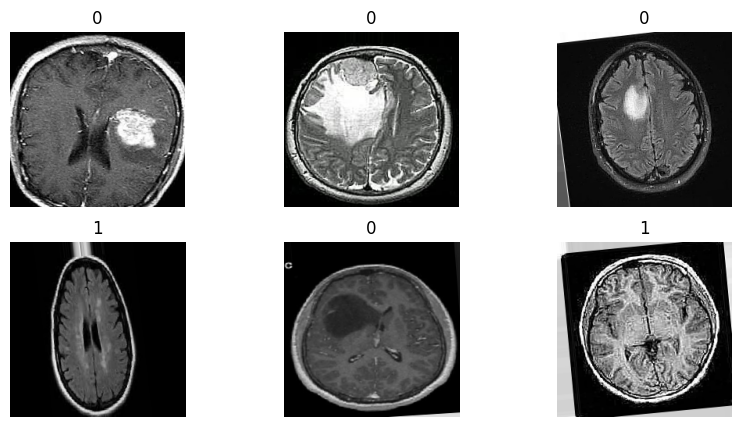

In [ ]:
plt.figure(figsize=(10,5))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    plt.title(int(labels[i]))
    plt.axis('off')
plt.show()